In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import math, time, os
from datetime import datetime
from typing import List, Dict, Tuple

# ----------------------------
# CONFIG
# ----------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Bodega: volumen útil compartido (m^3)
VOLUME_LIMIT = 21.0

# Formatos y unidades
# Formatos de Compra: Botella 1L, Barril 30L
FORMAT_SIZE_LITERS = [1.0, 1.0, 1.0, 30.0, 30.0]

# Unidad de Venta simulada: 1.0
LITERS_PER_SELL_UNIT = [1.0, 1.0, 1.0, 1.0, 1.0]

# Factor de conversión
UNITS_PER_FORMAT = [FORMAT_SIZE_LITERS[i] / LITERS_PER_SELL_UNIT[i] for i in range(len(FORMAT_SIZE_LITERS))]
# Resultado: [1.0, 1.0, 1.0, 30.0, 30.0]

# Volumen para bodega (m3)
# 1 Litro = 0.001 m3. 30 Litros = 0.03 m3 (aprox barril)
VOL_PER_FORMAT = [0.0017, 0.0017, 0.0017, 0.048, 0.048] # Ajustado con un poco de espacio por el vidrio/metal

# Lead time y horizonte
LEAD_TIME_DAYS = 2
HORIZON_WEEKS = 52

# Costos
C_ORDER_FIXED = 8000.0
C_UNIT_ORDER = 30.0
# ----------------------------
# COSTO DE QUIEBRE POR PRODUCTO (pesos por litro)
# ----------------------------
C_STOCKOUT_PER_UNIT_VEC = np.array([
    100333.0,   # Ron
    121833.0,   # Gin
    78833.0,    # Pisco
    5177.0,     # Heineken
    5668.0      # Calafate
])
C_HOLD_PER_UNIT_PER_DAY = 0.5

# Merma diaria (equivalente a 0.002 semanal)
MERMA_RATE_PER_DAY = 1 - (1 - 0.002) ** (1 / 7.0)

# Producto info (PRECIOS Y COSTOS CALCULADOS POR LITRO)
# Fórmulas usadas:
# Tragos (Ron, Gin, Mistral): (Precio Vaso / 0.060 L)
# Cervezas (Heineken, Calafate): (Precio Schop / 0.5 L)

PRODUCT_INFO = [
    {'unit_price': 72222.0, 'unit_cost': 8000.0},   # P1 Ron ($6500/0.09)
    {'unit_price': 88888.0, 'unit_cost': 11500.0},   # P2 Gin ($8000/0.09)
    {'unit_price': 55555.0,  'unit_cost': 4500.0},    # P3 Mistral ($5000/0.06)
    {'unit_price': 7000.0,   'unit_cost': 1832.0},    # P4 Heineken ($3500/0.5)
    {'unit_price': 10000.0,  'unit_cost': 4332.0},    # P5 Calafate ($5000/0.5)
]

# Distribuciones de demanda semanal por producto
DEMAND_CONFIG = [
    # P1 Ron (MOJITO) -> Gen. Extreme Value
    # EasyFit: k = -0.0785, s = 0.48646, m = 0.68026
    {'dist': 'genextreme', 'k': -0.0785, 's': 0.48646, 'm': 0.68026},

    # P2 Gin (PINK FLOWER) -> Gumbel Max
    # EasyFit: s = 0.32177, m = 0.32945
    {'dist': 'gumbel_r', 's': 0.32177, 'm': 0.32945},

    # P3 Mistral -> Gumbel Max
    # EasyFit: s = 0.25864, m = 0.28468
    {'dist': 'gumbel_r', 's': 0.25864, 'm': 0.28468},

    # P4 Heineken -> Gen. Extreme Value
    # EasyFit: k = 0.04147, s = 3.7087, m = 4.9781
    {'dist': 'genextreme', 'k': 0.04147, 's': 3.7087, 'm': 4.9781},

    # P5 Calafate -> Gen. Extreme Value
    # EasyFit: k = 0.06181, s = 2.4768, m = 2.8174
    {'dist': 'genextreme', 'k': 0.06181, 's': 2.4768, 'm': 2.8174},
]

# Topes de inventario máximo (en unidades)
S_MAX_UNITS = [100, 100, 100, 120, 120]
S_MAX_FORMATS = [int(math.ceil(S_MAX_UNITS[i] / UNITS_PER_FORMAT[i])) for i in range(len(S_MAX_UNITS))]

# ----------------------------
# PESOS DIARIOS POR PRODUCTO
# Orden días: [Lunes, Martes, Miércoles, Jueves, Viernes, Sábado, Domingo]
# ----------------------------

DAILY_WEIGHTS_MATRIX = np.array([
    # Ron
    [0.00, 0.097, 0.135, 0.191, 0.308, 0.269, 0.00],

    # Gin
    [0.00, 0.085, 0.123, 0.206, 0.299, 0.287, 0.00],

    # Mistral
    [0.00, 0.099, 0.218, 0.185, 0.305, 0.192, 0.00],

    # Heineken
    [0.00, 0.133, 0.133, 0.188, 0.307, 0.238, 0.00],

    # Austral Calafate
    [0.00, 0.123, 0.183, 0.185, 0.288, 0.221, 0.00],
])

# Normalización automática
DAILY_WEIGHTS_MATRIX = DAILY_WEIGHTS_MATRIX / DAILY_WEIGHTS_MATRIX.sum(axis=1, keepdims=True)

# Montecarlo (ajusta para pruebas/producción)
MC_REPL_OPTIMIZATION = 30
MC_REPL_FINAL = 200

# ----------------------------
# UTILIDADES
# ----------------------------
def ci95(arr):
    arr = np.array(arr)
    n = len(arr)
    if n <= 1:
        v = float(np.mean(arr)) if n == 1 else 0.0
        return (v, v)
    mean = float(np.mean(arr))
    se = float(np.std(arr, ddof=1) / math.sqrt(n))
    return (mean - 1.96 * se, mean + 1.96 * se)

def units_to_formats(needed_units, idx):
    upf = UNITS_PER_FORMAT[idx]
    fmt = int(math.ceil(max(0.0, needed_units) / upf - 1e-12))
    return fmt, fmt * upf

def allocate_weekly_to_days(weekly_count, rng, weights):
    # Multiplicamos por 1000 para convertir los litros en "mililitros" (enteros)
    n_ml = int(round(max(0, weekly_count) * 1000))

    if n_ml == 0:
        return np.zeros(7, dtype=float)

    # Distribuimos los mililitros usando la multinomial
    daily_ml = rng.multinomial(n_ml, weights)

    # Volvemos a dividir por 1000 para devolver el valor exacto en litros (con decimales)
    return daily_ml / 1000.0

def sample_weekly_demand(cfg, n_weeks, rng):

    dist_name = cfg['dist']
    total_days = n_weeks * 7

    # 1.- GUMBEL MAX
    if dist_name == 'gumbel_r':
        demand_daily = stats.gumbel_r.rvs(loc=cfg['m'], scale=cfg['s'], size=total_days, random_state=rng)

    # 2.- GENERALIZED EXTREME VALUE (GEV)
    elif dist_name == 'genextreme':
        c_scipy = -cfg['k']
        demand_daily = stats.genextreme.rvs(c=c_scipy, loc=cfg['m'], scale=cfg['s'], size=total_days, random_state=rng)

    else:
        raise ValueError(f"Distribución {dist_name} no soportada")

    # EVITAR DEMANDAS NEGATIVAS
    demand_daily = np.clip(demand_daily, a_min=0.0, a_max=None)

    # Agrupar por semanas (sumando bloques de 7 días)
    return demand_daily.reshape(n_weeks, 7).sum(axis=1)
# ----------------------------
# SIMULACIÓN DIARIA (CORREGIDA PARA LITROS)
# ----------------------------
def simulate_daily_shared(s_vec: List[int], S_vec: List[int],
                          params_list=DEMAND_CONFIG,
                          lead_time_days=LEAD_TIME_DAYS,
                          horizon_weeks=HORIZON_WEEKS,
                          repl=MC_REPL_FINAL, seed=RANDOM_SEED,
                          initial_formats: List[int] = None,
                          verbose=False,
                          return_full_dfs=True):
    rng_base = np.random.default_rng(seed)
    P = len(params_list)
    total_days = horizon_weeks * 7

    metrics_costs, metrics_revenues, metrics_profits = [], [], []
    metrics_fill, metrics_occup = [], []
    df_daily_first = pd.DataFrame()
    orders_all, arrivals_all = [], []

    for r in range(repl):
        rng = np.random.default_rng(rng_base.integers(1_000_000_000))

        # Demanda semanal -> diaria
        weekly_demands = [sample_weekly_demand(params_list[i], horizon_weeks, rng) for i in range(P)]
        daily_demands = np.zeros((P, total_days), dtype=float)
        for i in range(P):
            for w in range(horizon_weeks):
                wk = float(weekly_demands[i][w])
                alloc = allocate_weekly_to_days(wk, rng, DAILY_WEIGHTS_MATRIX[i])
                day_start = w * 7
                daily_demands[i, day_start:day_start + 7] = alloc

        # Inventario inicial
        if initial_formats is None:
            formats_closed = np.zeros(P, dtype=int)
        else:
            formats_closed = np.array(initial_formats, dtype=int)

        open_liters = np.zeros(P, dtype=float)

        pipeline: Dict[int, List[Tuple[int, int]]] = {}
        orders_log, arrivals_log = [], []
        cost_acc = 0.0
        served_cum = np.zeros(P)
        demand_cum = np.zeros(P)
        occupied_hist = []
        daily_log = []

        for day in range(total_days):
            dow = day % 7

            # Llegadas
            if day in pipeline:
                for (prod_idx, qty_formats) in pipeline[day]:
                    formats_closed[prod_idx] += int(qty_formats)
                    if return_full_dfs:
                        arrivals_log.append({'replica': r + 1, 'día_llegada': day + 1, 'producto': prod_idx + 1,
                                             'formatos_llegaron': int(qty_formats)})
                        arrivals_all.append(arrivals_log[-1])
                del pipeline[day]

            # Volumen ocupado
            occupied_volume = 0.0
            for i in range(P):
                # +1 si hay algo abierto
                n_fmt = formats_closed[i] + (1 if open_liters[i] > 1e-9 else 0)
                occupied_volume += n_fmt * VOL_PER_FORMAT[i]
            occupied_hist.append(occupied_volume)

            # SERVIR DEMANDA
            served_today = np.zeros(P)
            lost_today = np.zeros(P)
            inv_init_formats = formats_closed.copy()
            inv_init_open_liters = open_liters.copy()

            for i in range(P):
                dem = float(daily_demands[i, day])
                demand_cum[i] += dem

                units_open = open_liters[i] / LITERS_PER_SELL_UNIT[i] if open_liters[i] > 1e-9 else 0.0
                units_closed = formats_closed[i] * UNITS_PER_FORMAT[i]
                avail_units = units_open + units_closed

                if avail_units >= dem - 1e-9:
                    to_serve = dem
                    # Servir del abierto primero
                    if open_liters[i] > 1e-9:
                        units_from_open = min(units_open, to_serve)
                        liters_consumed = units_from_open * LITERS_PER_SELL_UNIT[i]
                        open_liters[i] = max(0.0, open_liters[i] - liters_consumed)
                        to_serve -= units_from_open
                        served_today[i] += units_from_open
                        if open_liters[i] < 1e-6: open_liters[i] = 0.0

                    # Abrir nuevos formatos si es necesario
                    while to_serve > 1e-9 and formats_closed[i] > 0:
                        formats_closed[i] -= 1
                        open_liters[i] += FORMAT_SIZE_LITERS[i]

                        # Si sobró un poco del anterior
                        if open_liters[i] > FORMAT_SIZE_LITERS[i] + 1e-9:
                            extra = open_liters[i] - FORMAT_SIZE_LITERS[i]
                            # Si sobra más de un formato entero, lo devolvemos a cerrado
                            extra_fmt = int(math.floor(extra / FORMAT_SIZE_LITERS[i] + 1e-12))
                            if extra_fmt > 0:
                                formats_closed[i] += extra_fmt
                                open_liters[i] -= extra_fmt * FORMAT_SIZE_LITERS[i]

                        units_from_new = min(open_liters[i] / LITERS_PER_SELL_UNIT[i], to_serve)
                        liters_consumed = units_from_new * LITERS_PER_SELL_UNIT[i]
                        open_liters[i] = max(0.0, open_liters[i] - liters_consumed)
                        to_serve -= units_from_new
                        served_today[i] += units_from_new

                        if open_liters[i] < 1e-6: open_liters[i] = 0.0
                        if to_serve < 1e-9: break
                else:
                    # Stockout parcial
                    # 1.- Consumir todo lo abierto
                    if open_liters[i] > 1e-9:
                        units_from_open = open_liters[i] / LITERS_PER_SELL_UNIT[i]
                        served_today[i] += units_from_open
                        open_liters[i] = 0.0

                    # 2.- Consumir todo lo cerrado
                    while formats_closed[i] > 0:
                        formats_closed[i] -= 1
                        open_liters[i] += FORMAT_SIZE_LITERS[i]

                        if open_liters[i] > FORMAT_SIZE_LITERS[i] + 1e-9:
                            extra = open_liters[i] - FORMAT_SIZE_LITERS[i]
                            extra_fmt = int(math.floor(extra / FORMAT_SIZE_LITERS[i] + 1e-12))
                            if extra_fmt > 0:
                                formats_closed[i] += extra_fmt
                                open_liters[i] -= extra_fmt * FORMAT_SIZE_LITERS[i]

                        units_from_new = min(open_liters[i] / LITERS_PER_SELL_UNIT[i], dem - served_today[i])
                        liters_consumed = units_from_new * LITERS_PER_SELL_UNIT[i]
                        open_liters[i] = max(0.0, open_liters[i] - liters_consumed)
                        served_today[i] += units_from_new

                        if open_liters[i] < 1e-6: open_liters[i] = 0.0
                        if served_today[i] >= dem - 1e-9: break

                    if served_today[i] < dem - 1e-9:
                        lost_today[i] = dem - served_today[i]
                        cost_acc += C_STOCKOUT_PER_UNIT_VEC[i] * lost_today[i]

                served_cum[i] += served_today[i]

            units_on_hand = np.array([open_liters[i] / LITERS_PER_SELL_UNIT[i] + formats_closed[i] * UNITS_PER_FORMAT[i] for i in range(P)])
            holding_cost_day = float(np.sum(units_on_hand * C_HOLD_PER_UNIT_PER_DAY))
            cost_acc += holding_cost_day

            # ORDER DECISION (s,S)
            orders_today = [0] * P
            units_ordered_today = 0.0
            any_order = False

            # Volumen actual ocupado
            current_vol = sum((formats_closed[i] + (1 if open_liters[i] > 1e-9 else 0)) * VOL_PER_FORMAT[i] for i in range(P))

            # Volumen ya comprometido en pedidos en tránsito
            vol_pipeline = 0.0
            for arrival_day, items in pipeline.items():
                for (prod_idx, qty) in items:
                    vol_pipeline += qty * VOL_PER_FORMAT[prod_idx]

            vol_free = max(0.0, VOLUME_LIMIT - (current_vol + vol_pipeline))

            for i in range(P):

                # ===============================
                # INVENTARIO POSICIÓN CORRECTO
                # ===============================

                # Inventario disponible
                inv_on_hand = open_liters[i] / LITERS_PER_SELL_UNIT[i] + formats_closed[i] * UNITS_PER_FORMAT[i]

                # Inventario en tránsito (Pipeline) solo del producto i
                pipeline_units_i = 0.0
                for arrival_day, items in pipeline.items():
                    for (prod_idx, qty_formats) in items:
                        if prod_idx == i:
                            pipeline_units_i += qty_formats * UNITS_PER_FORMAT[i]

                # Inventario Posición = Inventario disponible + Pipeline
                inventory_position = inv_on_hand + pipeline_units_i

                # Bloquea múltiples pedidos simultáneos
                already_ordered = pipeline_units_i > 0

                # ===============================
                # REGLA (s,S) CORRECTA
                # ===============================
                if inventory_position <= s_vec[i] + 1e-9 and not already_ordered:

                    needed_units = max(0.0, S_vec[i] - inventory_position)
                    fmt_needed, _ = units_to_formats(needed_units, i)

                    vol_needed = fmt_needed * VOL_PER_FORMAT[i]

                    if vol_needed > vol_free + 1e-12:
                        fmt_to_order = int(math.floor(vol_free / VOL_PER_FORMAT[i] + 1e-12))
                    else:
                        fmt_to_order = int(fmt_needed)

                    fmt_to_order = min(fmt_to_order, S_MAX_FORMATS[i])

                    if fmt_to_order > 0:
                        arrival_day = day + lead_time_days
                        pipeline.setdefault(arrival_day, []).append((i, fmt_to_order))

                        if return_full_dfs:
                            orders_log.append({
                                'replica': r + 1,
                                'día_pedido': day + 1,
                                'producto': i + 1,
                                'formatos_pedidos': int(fmt_to_order),
                                'día_llegada_esperada': int(arrival_day + 1)
                            })
                            orders_all.append(orders_log[-1])

                        orders_today[i] = fmt_to_order
                        units_ordered_today += fmt_to_order * UNITS_PER_FORMAT[i]
                        vol_free -= fmt_to_order * VOL_PER_FORMAT[i]
                        vol_free = max(0.0, vol_free)
                        any_order = True

            if any_order:
                cost_acc += C_ORDER_FIXED
                cost_acc += C_UNIT_ORDER * units_ordered_today


            # MERMA COST
            for i in range(P):
                if open_liters[i] > 0:
                    liters_init = open_liters[i]
                    open_liters[i] = max(0.0, open_liters[i] * (1.0 - MERMA_RATE_PER_DAY))
                    liters_lost = liters_init - open_liters[i]
                    units_lost = liters_lost / LITERS_PER_SELL_UNIT[i]
                    cost_acc += units_lost * PRODUCT_INFO[i]['unit_cost']

                    if open_liters[i] > FORMAT_SIZE_LITERS[i] + 1e-9:
                        extra = open_liters[i] - FORMAT_SIZE_LITERS[i]
                        extra_fmt = int(math.floor(extra / FORMAT_SIZE_LITERS[i] + 1e-12))
                        if extra_fmt > 0:
                            open_liters[i] -= extra_fmt * FORMAT_SIZE_LITERS[i]
                            formats_closed[i] += extra_fmt

            if r == 0 and return_full_dfs:
                for i in range(P):
                    inv_final_formats = formats_closed[i]
                    inv_final_open_liters = open_liters[i]
                    inv_final_units = inv_final_open_liters / LITERS_PER_SELL_UNIT[i] + inv_final_formats * UNITS_PER_FORMAT[i]

                    inv_init_formats_val = inv_init_formats[i]
                    inv_init_open_liters_val = inv_init_open_liters[i]
                    inv_init_units_val = inv_init_open_liters_val / LITERS_PER_SELL_UNIT[i] + inv_init_formats_val * UNITS_PER_FORMAT[i]

                    df_record = {
                        'replica': r + 1,
                        'día': day + 1,
                        'semana_operativa': (day // 7) + 1,
                        'nombre_dia': {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}[dow],
                        'producto': i + 1,
                        'inv_inicial_formatos': int(inv_init_formats_val),
                        'inv_inicial_open_liters': float(round(inv_init_open_liters_val, 6)),
                        'inv_inicial_unidades': float(round(inv_init_units_val, 6)),
                        'demanda_unidades': float(daily_demands[i, day]),
                        'servido_unidades_hoy': float(round(served_today[i], 6)),
                        'perdida_unidades_hoy': float(round(lost_today[i], 6)),
                        'merma_unidades_hoy': float(round((inv_init_open_liters_val - open_liters[i]) / LITERS_PER_SELL_UNIT[i] - served_today[i] + lost_today[i] if inv_init_open_liters_val>0 else 0.0, 6)),
                        'inv_final_formatos': int(inv_final_formats),
                        'inv_final_open_liters': float(round(inv_final_open_liters, 6)),
                        'inv_final_unidades': float(round(inv_final_units, 6)),
                        's_unidades': int(s_vec[i]),
                        'S_unidades': int(S_vec[i]),
                        'orden_formatos_hoy': int(orders_today[i]),
                        'dia_llegada_esperada': int(day + lead_time_days + 1) if orders_today[i] > 0 else None
                    }
                    daily_log.append(df_record)

        # Metricas por réplica
        revenue = float(np.sum(served_cum * np.array([PRODUCT_INFO[i]['unit_price'] for i in range(P)])))
        profit = revenue - cost_acc
        if not np.isfinite(profit): profit = -np.inf

        metrics_costs.append(cost_acc)
        metrics_revenues.append(revenue)
        metrics_profits.append(profit)
        metrics_fill.append(np.divide(served_cum, np.where(demand_cum > 0, demand_cum, 1.0)))
        metrics_occup.append(float(np.mean(occupied_hist)) if occupied_hist else 0.0)

        if r == 0 and return_full_dfs:
            df_daily_first = pd.DataFrame(daily_log)

    # Agregados Monte Carlo
    mean_cost_week = float(np.mean(metrics_costs) / HORIZON_WEEKS) if len(metrics_costs) > 0 else 0.0
    ci_cost_week = ci95(np.array(metrics_costs) / HORIZON_WEEKS) if len(metrics_costs) > 0 else (0, 0)
    mean_rev_week = float(np.mean(metrics_revenues) / HORIZON_WEEKS) if len(metrics_revenues) > 0 else 0.0
    mean_profit_week = float(np.mean(metrics_profits) / HORIZON_WEEKS) if len(metrics_profits) > 0 else 0.0
    ci_profit_week = ci95(np.array(metrics_profits) / HORIZON_WEEKS) if len(metrics_profits) > 0 else (0, 0)
    mean_fill = np.mean(np.stack(metrics_fill), axis=0) if len(metrics_fill) > 0 else np.zeros(P)
    ci_fill = [ci95(np.array([m[i] for m in metrics_fill])) if len(metrics_fill) > 0 else (0, 0) for i in range(P)]
    mean_occup = float(np.mean(metrics_occup)) if len(metrics_occup) > 0 else 0.0
    ci_occup = ci95(metrics_occup) if len(metrics_occup) > 0 else (0, 0)

    # Construcción de DataFrames de salida
    if return_full_dfs and not df_daily_first.empty:
        df_semanal = df_daily_first.groupby(['semana_operativa', 'producto']).agg(
            Inicial_Form=('inv_inicial_formatos', 'first'),
            Inicial_OpenLiters=('inv_inicial_open_liters', 'first'),
            Total_Up=('demanda_unidades', 'sum'),
            Total_Us=('servido_unidades_hoy', 'sum'),
            Total_Ul=('perdida_unidades_hoy', 'sum'),
            Final_Form=('inv_final_formatos', 'last'),
            Ordenes_Total_Formato=('orden_formatos_hoy', 'sum')
        ).reset_index()
        df_orders = pd.DataFrame(orders_all)
        df_arrivals = pd.DataFrame(arrivals_all)
    else:
        df_semanal = df_orders = df_arrivals = pd.DataFrame()

    metrics = {
        'mean_cost_per_week': mean_cost_week,
        'ci_cost_per_week': ci_cost_week,
        'mean_revenue_per_week': mean_rev_week,
        'mean_profit_per_week': mean_profit_week,
        'ci_profit_per_week': ci_profit_week,
        'fill_rate_per_product': mean_fill.tolist(),
        'ci_fill_rate_per_product': ci_fill,
        'avg_occupation_m3': mean_occup,
        'ci_occupation_m3': ci_occup
    }

    return metrics, df_daily_first, df_semanal, df_orders, df_arrivals

# ----------------------------
# ENCONTRAR ÓPTIMO
# ----------------------------
def _is_finite_number(x):
    try:
        return np.isfinite(x)
    except Exception:
        return False

def find_optimal_policy_seq(P: int, s_init: List[int], S_init: List[int],
                            max_units: List[int], initial_formats: List[int],
                            verbose: bool = False) -> Tuple[List[int], List[int]]:

    print("Iniciando optimización secuencial (Warm Start)")
    start_time = time.time()

    optimal_s = s_init[:]
    optimal_S = S_init[:]

    for i in range(P):
        best_profit_i = -np.inf
        best_s_i = optimal_s[i]
        best_S_i = optimal_S[i]

        # Rango de búsqueda
        s_min = max(0, s_init[i] - 15)
        s_max = min(s_init[i] + 15, max_units[i])
        S_min = max(s_min, 0)
        S_max = min(max_units[i], S_init[i] + 30)

        s_range = list(range(s_min, s_max + 1))
        S_range = list(range(S_min, S_max + 1))

        if verbose:
            print(f"Producto {i+1}: s_range {s_min}-{s_max}, S_range {S_min}-{S_max}")

        for s_cand in s_range:
            for S_cand in S_range:
                if S_cand <= s_cand: # s debe ser estrictamente menor a S para que tenga sentido lógico
                    continue

                # Configuramos vector de prueba
                s_trial = optimal_s[:]
                S_trial = optimal_S[:]
                s_trial[i] = int(s_cand)
                S_trial[i] = int(S_cand)

                trial_initial_formats = initial_formats[:]

                # Para el producto 'i' que optimizamos, forzamos el inventario inicial a S_cand
                # Convertimos unidades S (tragos) a formatos (botellas)
                fmt_trial = int(math.ceil(S_cand / UNITS_PER_FORMAT[i]))
                trial_initial_formats[i] = fmt_trial
                # -------------------------------

                try:
                    metrics, _, _, _, _ = simulate_daily_shared(
                        s_trial, S_trial,
                        repl=MC_REPL_OPTIMIZATION,
                        horizon_weeks=12,
                        seed=RANDOM_SEED,
                        initial_formats=trial_initial_formats,
                        return_full_dfs=False
                    )
                except Exception as e:
                    continue

                profit = metrics.get('mean_profit_per_week', None)
                if not _is_finite_number(profit):
                    continue

                if profit > best_profit_i:
                    best_profit_i = profit
                    best_s_i = s_cand
                    best_S_i = S_cand

        optimal_s[i] = int(best_s_i)
        optimal_S[i] = int(best_S_i)
        print(f"-> P{i+1}: Óptimo parcial (s={best_s_i}, S={best_S_i}) profit_week={best_profit_i:,.2f}")

    end_time = time.time()
    print(f"Optimización finalizada en {end_time - start_time:.2f} s.")
    return optimal_s, optimal_S

# ----------------------------
# HEURÍSTICA INICIAL
# ----------------------------
def heuristic_initial(params_list=DEMAND_CONFIG):
    P = len(params_list)
    s_vec = []
    S_vec = []
    for i in range(P):
        rng = np.random.default_rng(100 + i)
        samp = sample_weekly_demand(params_list[i], 10000, rng)
        mu = float(np.mean(samp))
        daily_mean = mu / 7.0
        s = int(math.ceil(daily_mean * LEAD_TIME_DAYS))
        S = int(min(S_MAX_UNITS[i], max(1, math.ceil(mu * 1.5))))
        s_vec.append(s)
        S_vec.append(S)
    return s_vec, S_vec

# ----------------------------
# EXCEL
# ----------------------------
def export_excel_safe(df_diario, df_semanal, df_orders, df_arrivals, metrics: Dict,
                      filename_prefix="plan_semanal_compartido"):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"{filename_prefix}_OPT_{ts}.xlsx"
    df_diario_export = df_diario.copy() if df_diario is not None else pd.DataFrame()
    df_semanal_export = df_semanal.copy() if df_semanal is not None else pd.DataFrame()
    df_orders_export = df_orders.copy() if df_orders is not None else pd.DataFrame()
    df_arrivals_export = df_arrivals.copy() if df_arrivals is not None else pd.DataFrame()
    df_metrics = pd.DataFrame([metrics])

    try:
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            if not df_semanal_export.empty:
                df_semanal_export.to_excel(writer, sheet_name='Resumen_Semanal', index=False)
            if not df_diario_export.empty:
                df_diario_export.to_excel(writer, sheet_name='Detalle_Diario', index=False)
            if not df_orders_export.empty:
                df_orders_export.to_excel(writer, sheet_name='Pedidos_Colocados', index=False)
            if not df_arrivals_export.empty:
                df_arrivals_export.to_excel(writer, sheet_name='Pedidos_Llegadas', index=False)
            df_metrics.to_excel(writer, sheet_name='Metricas', index=False)
        print(f"Excel generado: {os.path.abspath(filename)}")
        return filename
    except Exception as e:
        print(f"Error al exportar Excel: {e}")
        return None

# ----------------------------
# EJECUCIÓN PRINCIPAL
# ----------------------------
if __name__ == "__main__":
    P = len(DEMAND_CONFIG)

    initial_formats_full = [int(math.ceil(S_MAX_UNITS[i] / UNITS_PER_FORMAT[i])) for i in range(P)]

    print("Inventario inicial (formatos cerrados - Bodega Llena) =", initial_formats_full)
    s_init, S_init = heuristic_initial()
    print("Heurística inicial (s, S):")
    print(s_init, S_init)

    # Optimización secuencial
    run_opt = True
    if run_opt:
        s_opt, S_opt = find_optimal_policy_seq(P, s_init, S_init, S_MAX_UNITS, initial_formats_full, verbose=True)
    else:
        s_opt, S_opt = s_init, S_init

    print("POLÍTICA FINAL (s*, S*):")
    print("s*:", s_opt)
    print("S*:", S_opt)

    initial_formats_optimal = [int(math.ceil(S_opt[i] / UNITS_PER_FORMAT[i])) for i in range(P)]
    print(f"Inventario Inicial Ajustado para Simulación (Formatos): {initial_formats_optimal}")

    print(f"\nCorriendo simulación final (réplicas={MC_REPL_FINAL})...")
    metrics, df_diario, df_semanal, df_orders, df_arrivals = simulate_daily_shared(
        s_opt, S_opt,
        lead_time_days=LEAD_TIME_DAYS,
        horizon_weeks=HORIZON_WEEKS,
        repl=MC_REPL_FINAL,
        seed=RANDOM_SEED,
        initial_formats=initial_formats_optimal,
        verbose=False,
        return_full_dfs=True
    )

    print("\nMétricas finales:")
    print(f"- Beneficio medio por semana: {metrics['mean_profit_per_week']:.2f} CI95 {metrics['ci_profit_per_week']}")
    print("- Fill rates por producto:", np.round(metrics['fill_rate_per_product'], 4))
    print("- Ocupación media (m3):", metrics['avg_occupation_m3'])

    print("== FIN ==")

Inventario inicial (formatos cerrados - Bodega Llena) = [100, 100, 100, 4, 4]
Heurística inicial (s, S):
[2, 2, 1, 15, 9] [10, 6, 5, 77, 47]
Iniciando optimización secuencial (Warm Start)
Producto 1: s_range 0-17, S_range 0-40
-> P1: Óptimo parcial (s=5, S=38) profit_week=365,723.96
Producto 2: s_range 0-17, S_range 0-36
-> P2: Óptimo parcial (s=4, S=34) profit_week=365,867.99
Producto 3: s_range 0-16, S_range 0-35
-> P3: Óptimo parcial (s=2, S=34) profit_week=365,877.88
Producto 4: s_range 0-30, S_range 0-107
-> P4: Óptimo parcial (s=30, S=107) profit_week=371,162.18
Producto 5: s_range 0-24, S_range 0-77
-> P5: Óptimo parcial (s=23, S=77) profit_week=374,266.11
Optimización finalizada en 1393.62 s.
POLÍTICA FINAL (s*, S*):
s*: [5, 4, 2, 30, 23]
S*: [38, 34, 34, 107, 77]
Inventario Inicial Ajustado para Simulación (Formatos): [38, 34, 34, 4, 3]

Corriendo simulación final (réplicas=200)...

Métricas finales:
- Beneficio medio por semana: 1612710.06 CI95 (1609182.6808286218, 1616237.44


GENERANDO GRÁFICOS DE SERIES DE TIEMPO Y TEST ADF


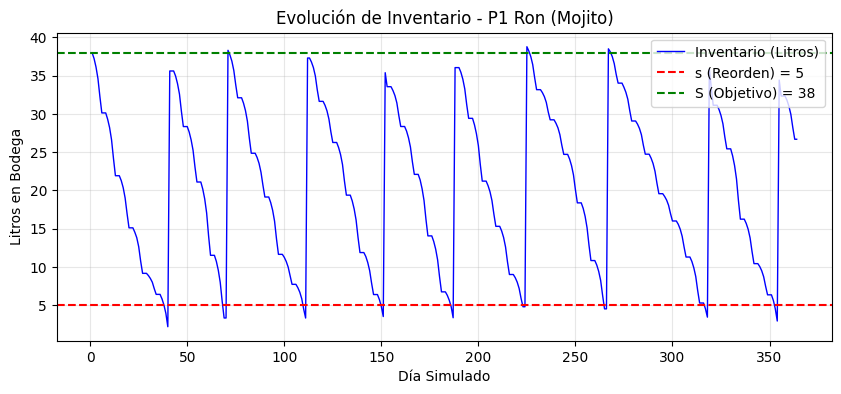


--- Resultados Test ADF: P1 Ron (Mojito) ---
Estadístico ADF: -5.2732
P-Valor: 6.2208e-06
>> RESULTADO: La serie ES ESTACIONARIA (Rechazamos H0).
>> INTERPRETACIÓN: El sistema de inventario es ESTABLE y está bajo control.
------------------------------------------------------------


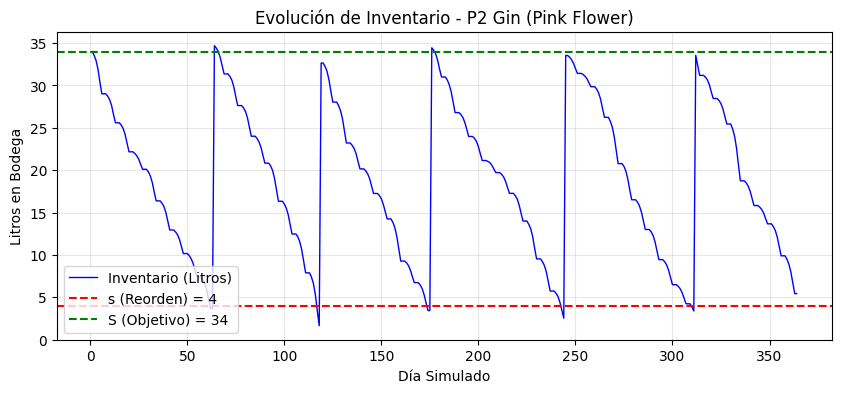


--- Resultados Test ADF: P2 Gin (Pink Flower) ---
Estadístico ADF: -4.0963
P-Valor: 9.8241e-04
>> RESULTADO: La serie ES ESTACIONARIA (Rechazamos H0).
>> INTERPRETACIÓN: El sistema de inventario es ESTABLE y está bajo control.
------------------------------------------------------------


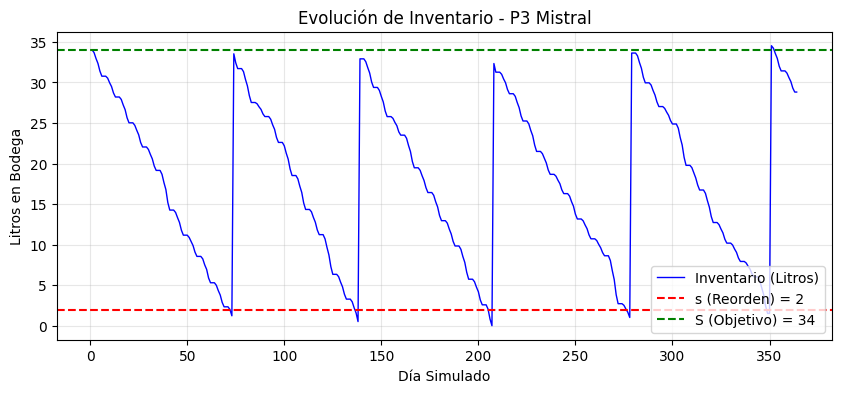


--- Resultados Test ADF: P3 Mistral ---
Estadístico ADF: -3.9793
P-Valor: 1.5231e-03
>> RESULTADO: La serie ES ESTACIONARIA (Rechazamos H0).
>> INTERPRETACIÓN: El sistema de inventario es ESTABLE y está bajo control.
------------------------------------------------------------


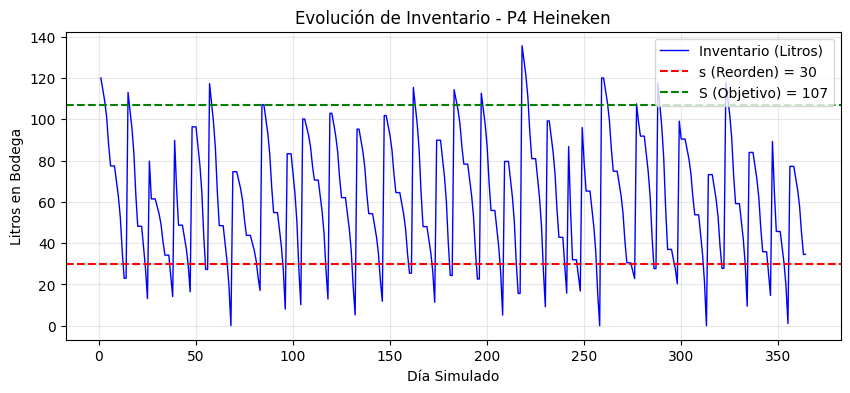


--- Resultados Test ADF: P4 Heineken ---
Estadístico ADF: -9.9668
P-Valor: 2.2951e-17
>> RESULTADO: La serie ES ESTACIONARIA (Rechazamos H0).
>> INTERPRETACIÓN: El sistema de inventario es ESTABLE y está bajo control.
------------------------------------------------------------


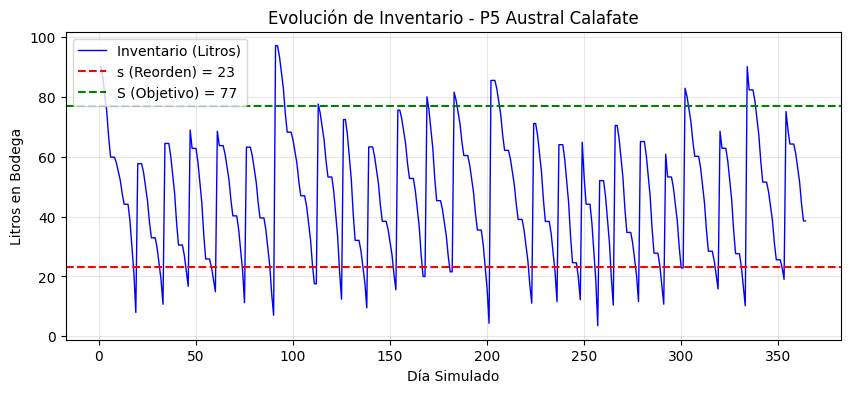


--- Resultados Test ADF: P5 Austral Calafate ---
Estadístico ADF: -5.4529
P-Valor: 2.6199e-06
>> RESULTADO: La serie ES ESTACIONARIA (Rechazamos H0).
>> INTERPRETACIÓN: El sistema de inventario es ESTABLE y está bajo control.
------------------------------------------------------------


In [3]:
# ==============================================================================
# GRÁFICOS Y VALIDACIÓN DE ESTACIONARIEDAD
# ==============================================================================
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

print("\n" + "="*60)
print("GENERANDO GRÁFICOS DE SERIES DE TIEMPO Y TEST ADF")
print("="*60)

productos_nombres = {
    1: "P1 Ron (Mojito)",
    2: "P2 Gin (Pink Flower)",
    3: "P3 Mistral",
    4: "P4 Heineken",
    5: "P5 Austral Calafate"
}


if df_diario is not None and not df_diario.empty:
    for p_id in range(1, 6): # Productos 1 al 5
        # 1. Filtrar datos del producto
        df_prod = df_diario[df_diario['producto'] == p_id].sort_values('día')

        # Serie de Tiempo de Interés: Inventario Final en Unidades (Litros)
        serie_inventario = df_prod['inv_final_unidades']
        dias = df_prod['día']

        # 2. Gráfico
        plt.figure(figsize=(10, 4))
        plt.plot(dias, serie_inventario, label='Inventario (Litros)', color='blue', linewidth=1)
        # Dibujar líneas de la política s, S
        s_val = df_prod['s_unidades'].iloc[0]
        S_val = df_prod['S_unidades'].iloc[0]
        plt.axhline(y=s_val, color='red', linestyle='--', label=f's (Reorden) = {s_val}')
        plt.axhline(y=S_val, color='green', linestyle='--', label=f'S (Objetivo) = {S_val}')

        plt.title(f"Evolución de Inventario - {productos_nombres[p_id]}")
        plt.xlabel("Día Simulado")
        plt.ylabel("Litros en Bodega")
        plt.legend()
        plt.grid(True, alpha=0.3)


        plt.show()

        # 3. Test de Estacionariedad (Augmented Dickey-Fuller)
        # H0: La serie NO es estacionaria (tiene raíz unitaria, es inestable)
        # H1: La serie ES estacionaria (es estable)
        print(f"\n--- Resultados Test ADF: {productos_nombres[p_id]} ---")
        try:
            resultado_adf = adfuller(serie_inventario)
            p_valor = resultado_adf[1]
            estadistico = resultado_adf[0]

            print(f"Estadístico ADF: {estadistico:.4f}")
            print(f"P-Valor: {p_valor:.4e}")

            if p_valor < 0.05:
                print(">> RESULTADO: La serie ES ESTACIONARIA (Rechazamos H0).")
                print(">> INTERPRETACIÓN: El sistema de inventario es ESTABLE y está bajo control.")
            else:
                print(">> RESULTADO: La serie NO es estacionaria (No rechazamos H0).")
                print(">> INTERPRETACIÓN: El inventario podría tener una tendencia o ser inestable.")
        except Exception as e:
            print(f"No se pudo calcular ADF (posiblemente datos constantes): {e}")

        print("-" * 60)

else:
    print("Error: No hay datos diarios (df_diario está vacío). Revisa que return_full_dfs=True")


GENERACIÓN DE GRÁFICOS PARA VALIDACIÓN: VENTAS E INVENTARIO


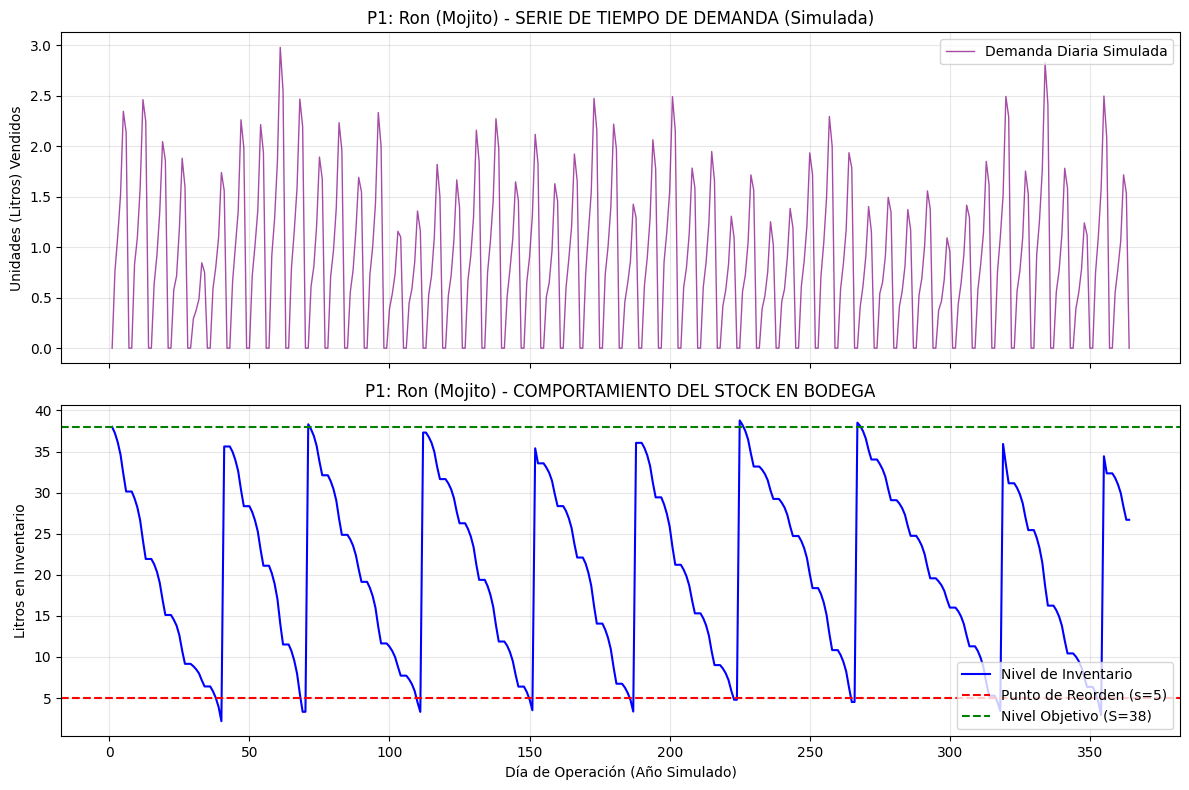

--------------------------------------------------------------------------------


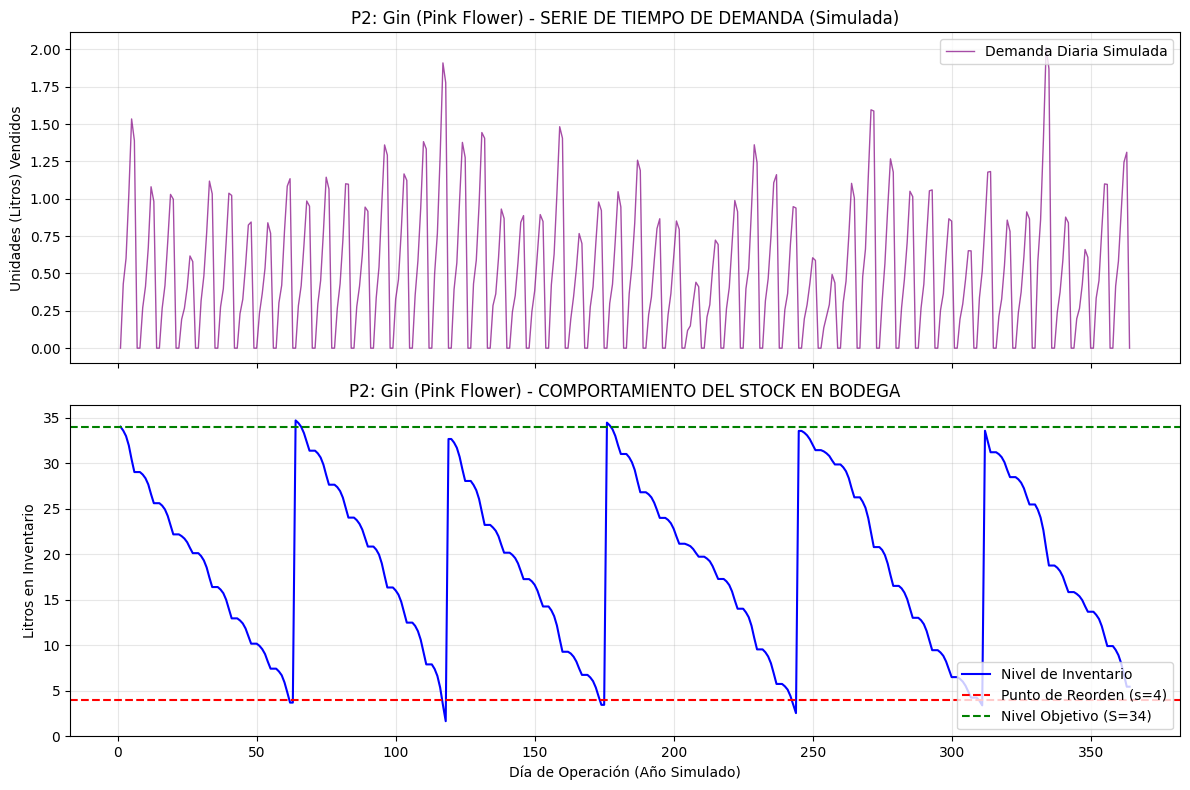

--------------------------------------------------------------------------------


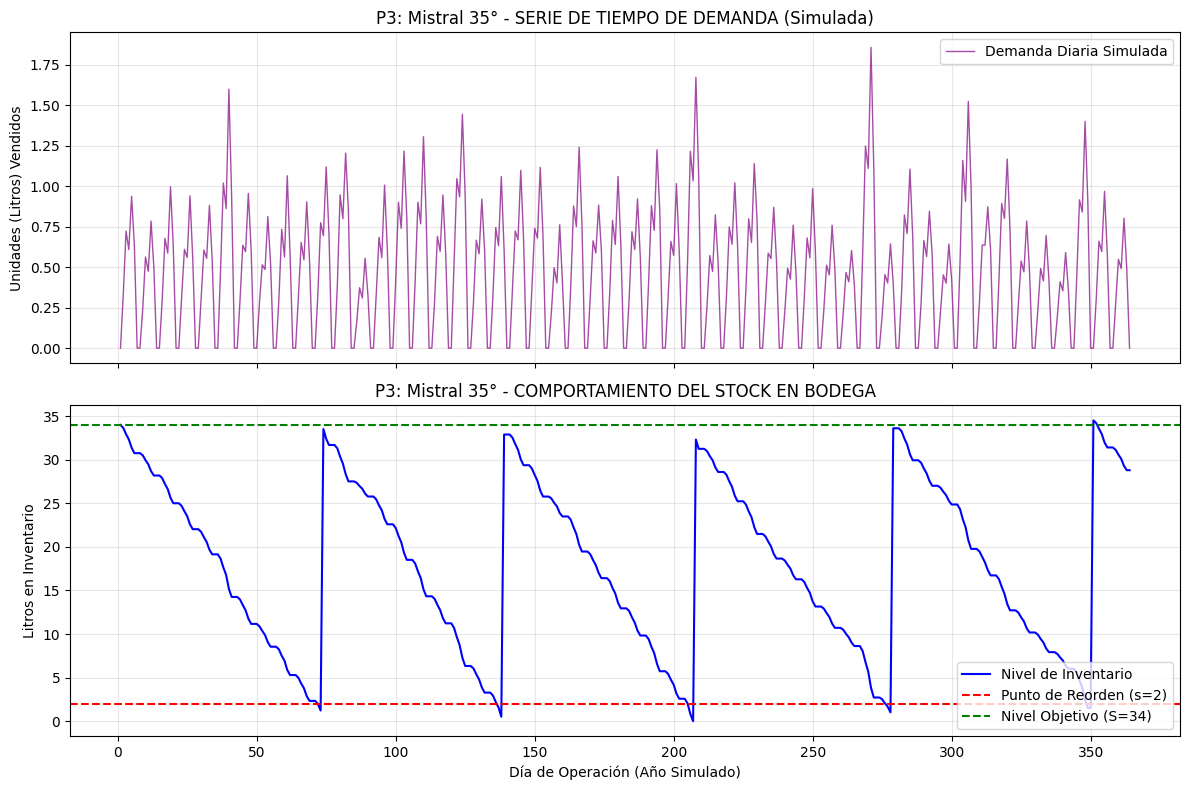

--------------------------------------------------------------------------------


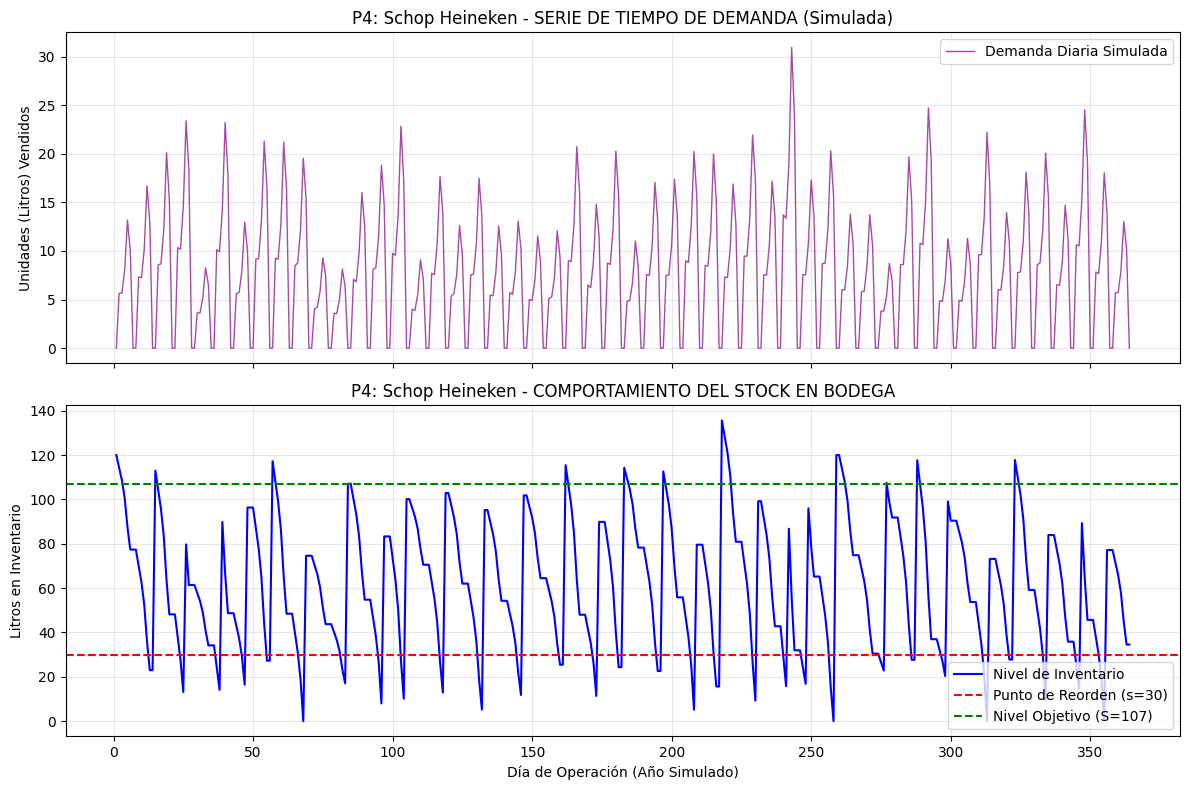

--------------------------------------------------------------------------------


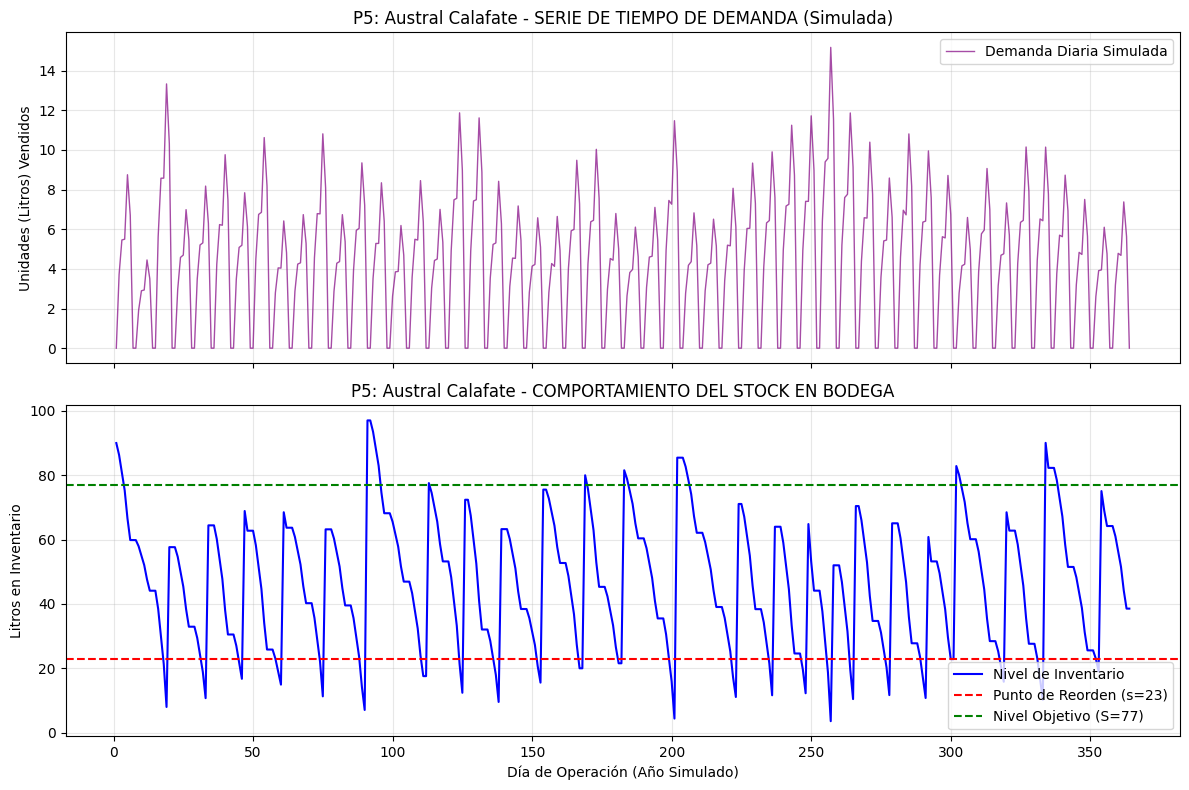

--------------------------------------------------------------------------------


In [4]:
# ==============================================================================
# GRÁFICOS COMPARATIVOS (VENTAS SIMULADAS vs INVENTARIO)
# ==============================================================================
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("GENERACIÓN DE GRÁFICOS PARA VALIDACIÓN: VENTAS E INVENTARIO")
print("="*80)

# Diccionario de nombres para los títulos
nombres_productos = {
    1: "P1: Ron (Mojito)",
    2: "P2: Gin (Pink Flower)",
    3: "P3: Mistral 35°",
    4: "P4: Schop Heineken",
    5: "P5: Austral Calafate"
}

if df_diario is not None and not df_diario.empty:
    for p_id in range(1, 6): # Recorrer los 5 productos

        # Filtrar datos de la primera réplica para el producto actual
        df_prod = df_diario[df_diario['producto'] == p_id].sort_values('día')

        dias = df_prod['día']
        ventas_simuladas = df_prod['demanda_unidades']  # Esto se compara con los datos históricos de R
        inventario = df_prod['inv_final_unidades']      # Esto muestra el desempeño de tu política

        # Crear una figura con dos sub-gráficos (uno arriba del otro)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        # --- GRÁFICO 1: VENTAS SIMULADAS (Para comparar con Histórico) ---
        # Usamos un gráfico de líneas finas o barras para que se parezca al ruido real
        ax1.plot(dias, ventas_simuladas, color='purple', alpha=0.7, linewidth=1, label='Demanda Diaria Simulada')
        ax1.set_title(f"{nombres_productos[p_id]} - SERIE DE TIEMPO DE DEMANDA (Simulada)")
        ax1.set_ylabel("Unidades (Litros) Vendidos")
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)

        # --- GRÁFICO 2: EVOLUCIÓN DEL INVENTARIO (Política s,S) ---
        ax2.plot(dias, inventario, color='blue', linewidth=1.5, label='Nivel de Inventario')

        # Dibujar las líneas de la política s y S
        s_val = s_opt[p_id-1]
        S_val = S_opt[p_id-1]
        ax2.axhline(y=s_val, color='red', linestyle='--', linewidth=1.5, label=f'Punto de Reorden (s={s_val})')
        ax2.axhline(y=S_val, color='green', linestyle='--', linewidth=1.5, label=f'Nivel Objetivo (S={S_val})')

        ax2.set_title(f"{nombres_productos[p_id]} - COMPORTAMIENTO DEL STOCK EN BODEGA")
        ax2.set_ylabel("Litros en Inventario")
        ax2.set_xlabel("Día de Operación (Año Simulado)")
        ax2.legend(loc='lower right')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        print("-" * 80)

else:
    print("Error: No hay datos en 'df_diario'. Asegúrate de correr la simulación con return_full_dfs=True")


GENERACIÓN DE GRÁFICOS PARA VALIDACIÓN: VENTAS E INVENTARIO


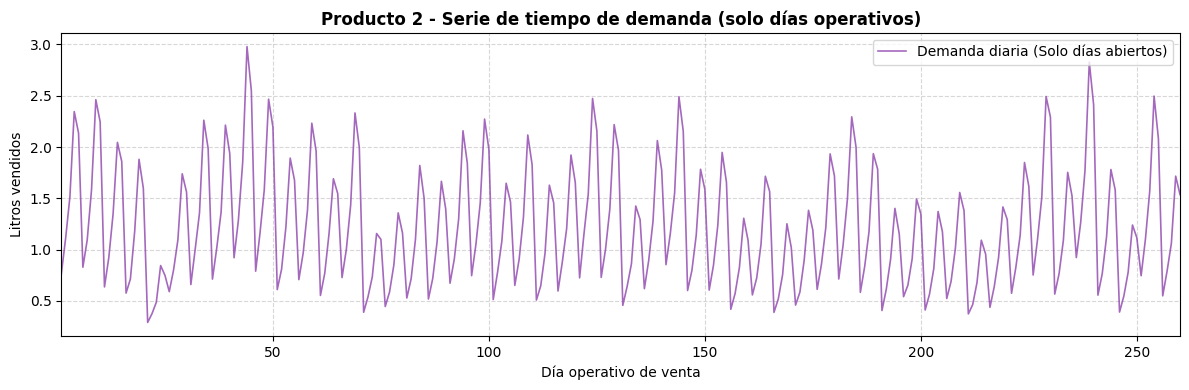

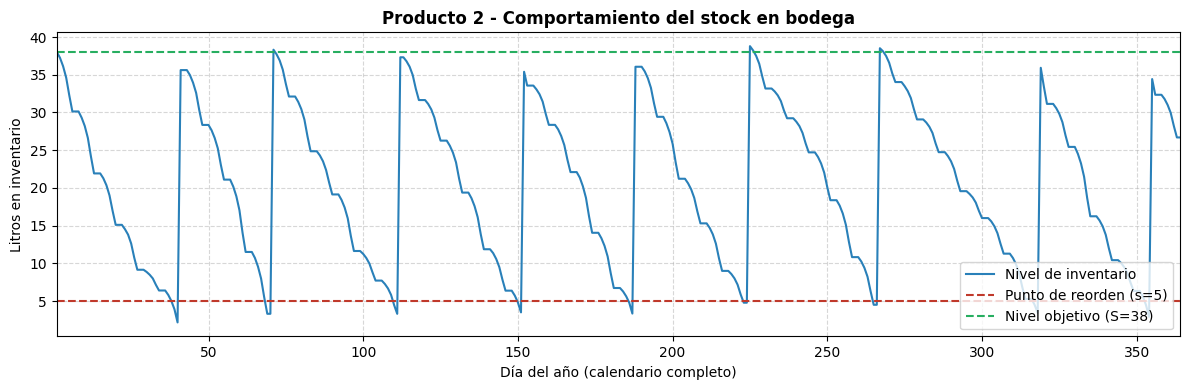

--------------------------------------------------------------------------------


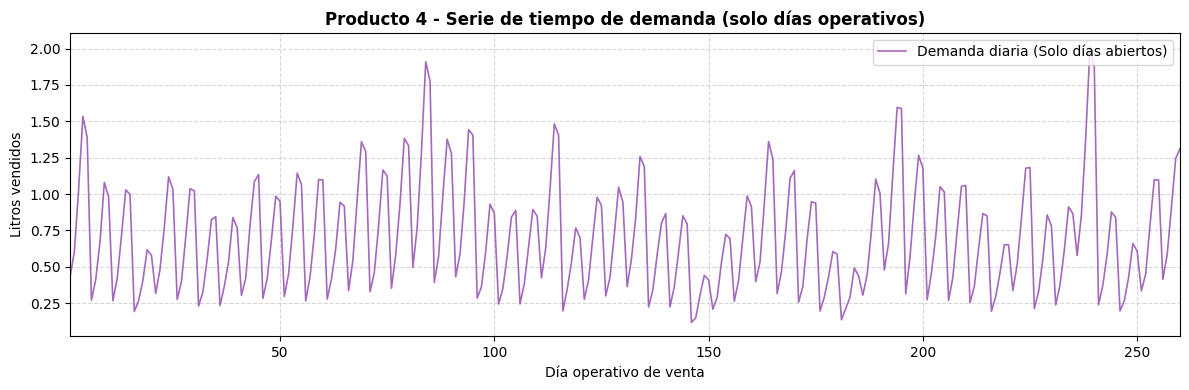

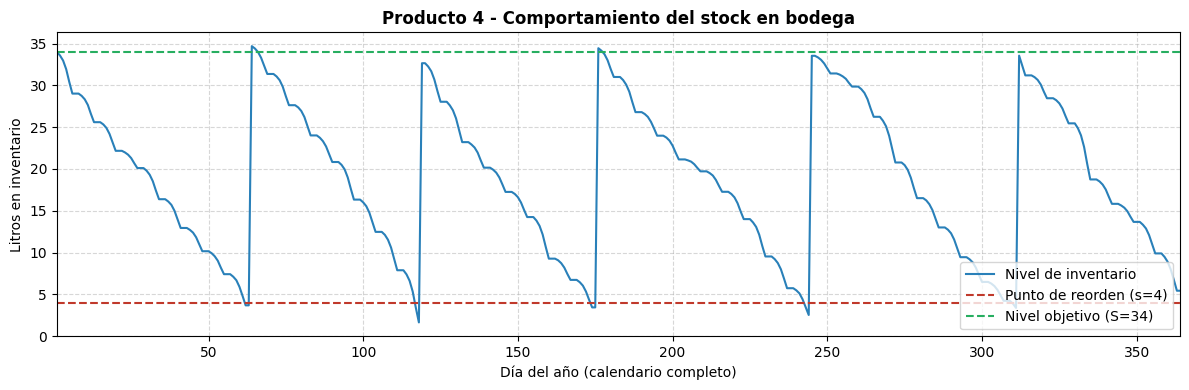

--------------------------------------------------------------------------------


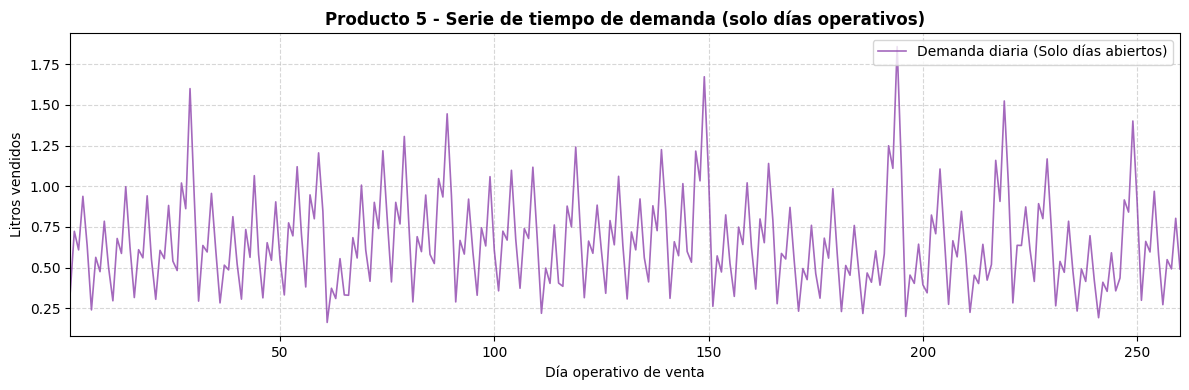

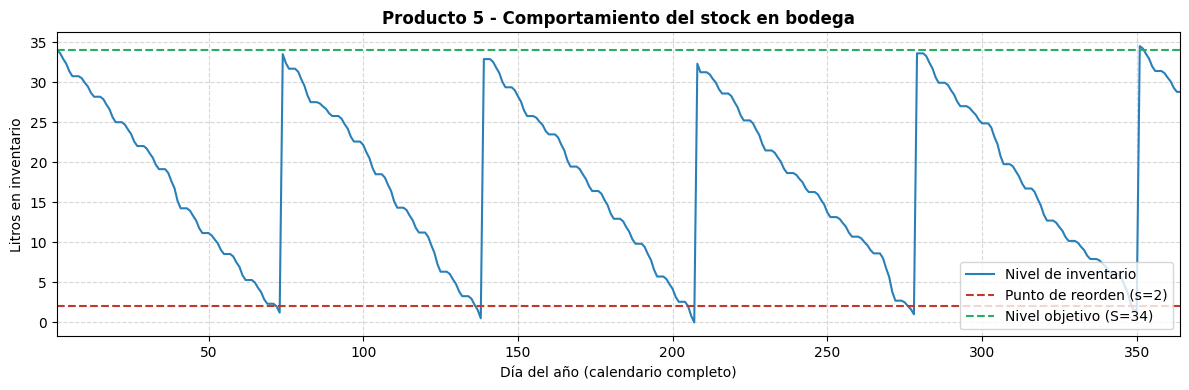

--------------------------------------------------------------------------------


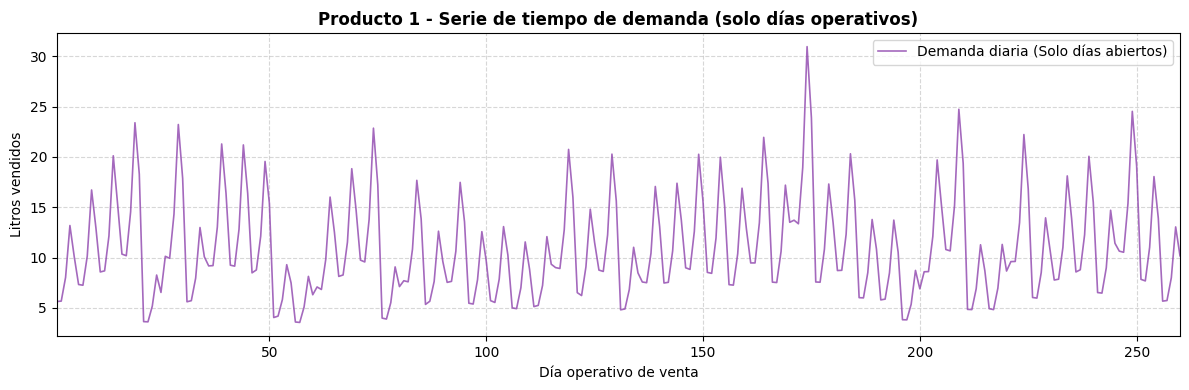

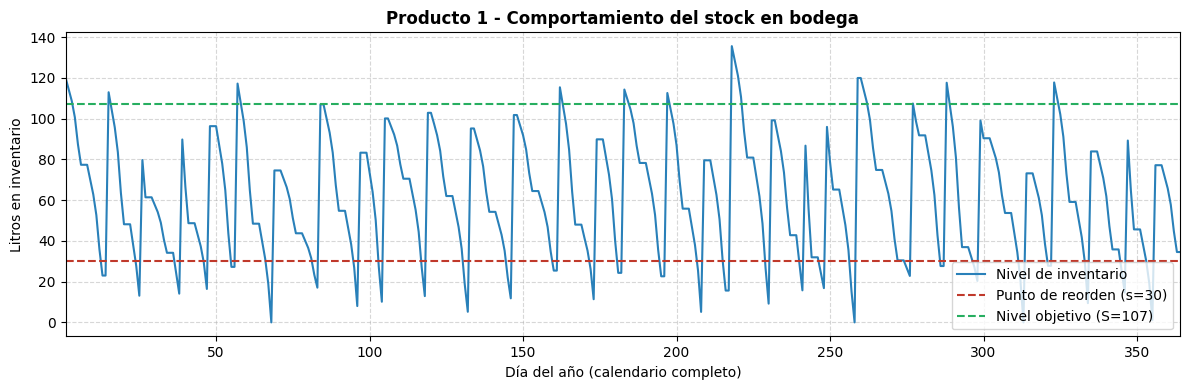

--------------------------------------------------------------------------------


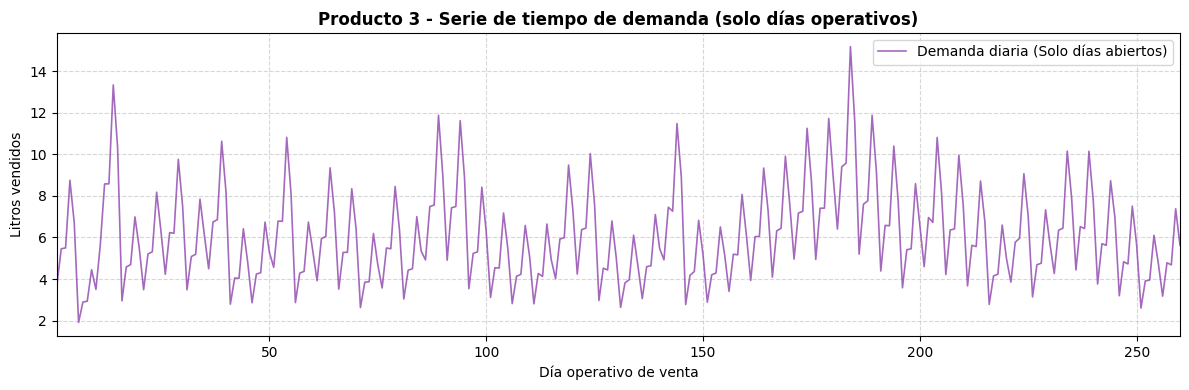

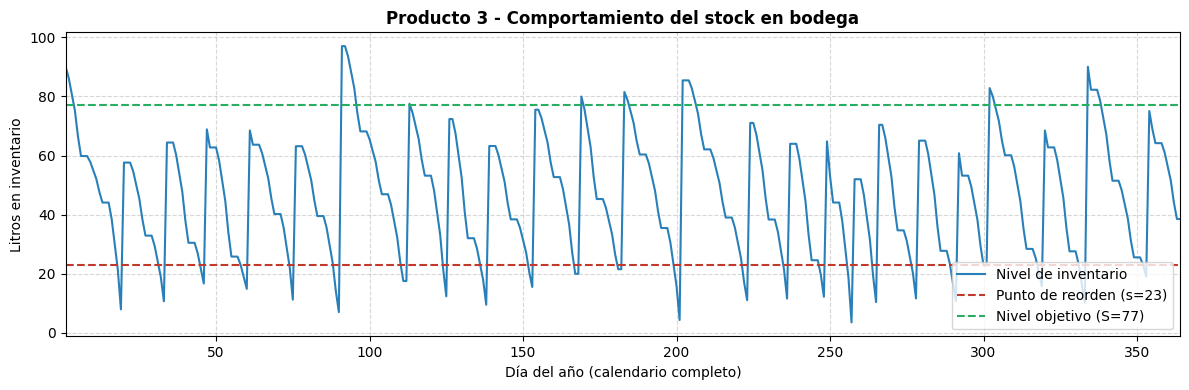

--------------------------------------------------------------------------------


In [5]:
# ==============================================================================
# GRÁFICOS VENTAS DÍAS OPERATIVOS E INVENTARIO
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*80)
print("GENERACIÓN DE GRÁFICOS PARA VALIDACIÓN: VENTAS E INVENTARIO")
print("="*80)

# Diccionario para mapear el ID interno de Python con el orden de la Tesis.
nombres_tesis = {
    1: "Producto 2",
    2: "Producto 4",
    3: "Producto 5",
    4: "Producto 1",
    5: "Producto 3"
}

if df_diario is not None and not df_diario.empty:
    for p_id in range(1, 6): # Recorrer los 5 productos

        # Filtrar datos de la primera réplica para el producto actual
        df_prod = df_diario[df_diario['producto'] == p_id].sort_values('día')

        # ---------------------------------------------------------
        # PREPARACIÓN DE DATOS PARA GRÁFICO 1 (DEMANDA - Solo días abiertos)
        # ---------------------------------------------------------
        # Filtramos excluyendo Lunes y Domingos
        df_demanda_abierta = df_prod[~df_prod['nombre_dia'].isin(['Lunes', 'Domingo'])]

        dias_operativos = np.arange(1, len(df_demanda_abierta) + 1)
        ventas_simuladas = df_demanda_abierta['demanda_unidades']

        # ---------------------------------------------------------
        # PREPARACIÓN DE DATOS PARA GRÁFICO 2 (INVENTARIO - Todos los días)
        # ---------------------------------------------------------
        dias_totales = df_prod['día']
        inventario = df_prod['inv_final_unidades']

        nombre_grafico = nombres_tesis[p_id]

        # ---------------------------------------------------------
        # GRÁFICO 1: VENTAS SIMULADAS (Días Operativos)
        # ---------------------------------------------------------
        plt.figure(figsize=(12, 4))
        plt.plot(dias_operativos, ventas_simuladas, color='#8E44AD', alpha=0.8, linewidth=1.2, label='Demanda diaria (Solo días abiertos)')

        plt.title(f"{nombre_grafico} - Serie de tiempo de demanda (solo días operativos)", fontsize=12, fontweight='bold')
        plt.ylabel("Litros vendidos", fontsize=10)
        plt.xlabel("Día operativo de venta", fontsize=10)

        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xlim(dias_operativos.min(), dias_operativos.max())

        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------------
        # GRÁFICO 2: EVOLUCIÓN DEL INVENTARIO (Política s,S)
        # ---------------------------------------------------------
        plt.figure(figsize=(12, 4))
        plt.plot(dias_totales, inventario, color='#2980B9', linewidth=1.5, label='Nivel de inventario')

        # Dibujar las líneas de la política s y S
        s_val = s_opt[p_id-1]
        S_val = S_opt[p_id-1]
        plt.axhline(y=s_val, color='#C0392B', linestyle='--', linewidth=1.5, label=f'Punto de reorden (s={s_val})')
        plt.axhline(y=S_val, color='#27AE60', linestyle='--', linewidth=1.5, label=f'Nivel objetivo (S={S_val})')

        plt.title(f"{nombre_grafico} - Comportamiento del stock en bodega", fontsize=12, fontweight='bold')
        plt.ylabel("Litros en inventario", fontsize=10)
        plt.xlabel("Día del año (calendario completo)", fontsize=10)

        plt.legend(loc='lower right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xlim(dias_totales.min(), dias_totales.max())

        plt.tight_layout()
        plt.show()

        print("-" * 80)

else:
    print("Error: No hay datos en 'df_diario'. Asegúrate de correr la simulación con return_full_dfs=True")


GENERACIÓN DE GRÁFICOS: DEMANDA (TRAGOS/SCHOPS) E INVENTARIO (LITROS)


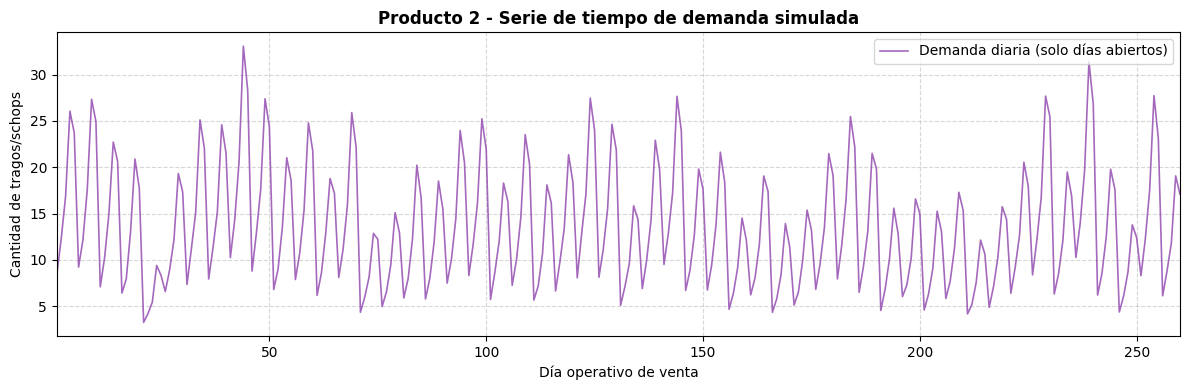

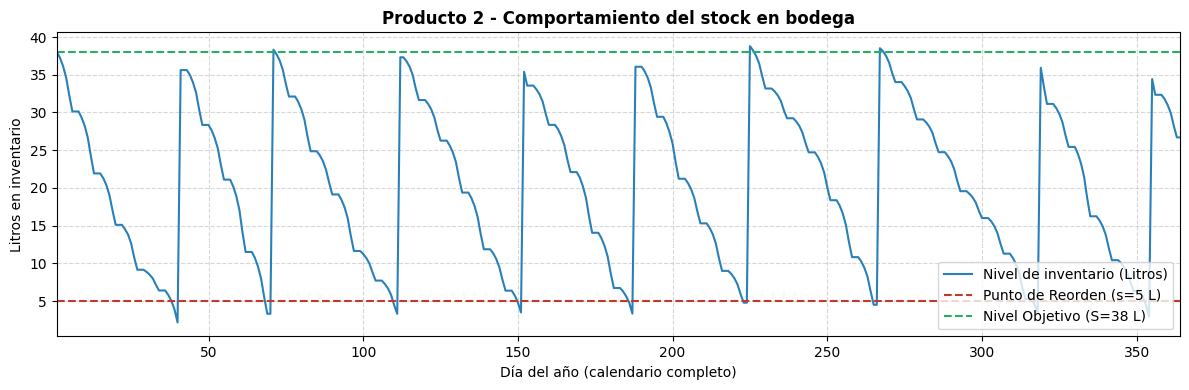

--------------------------------------------------------------------------------


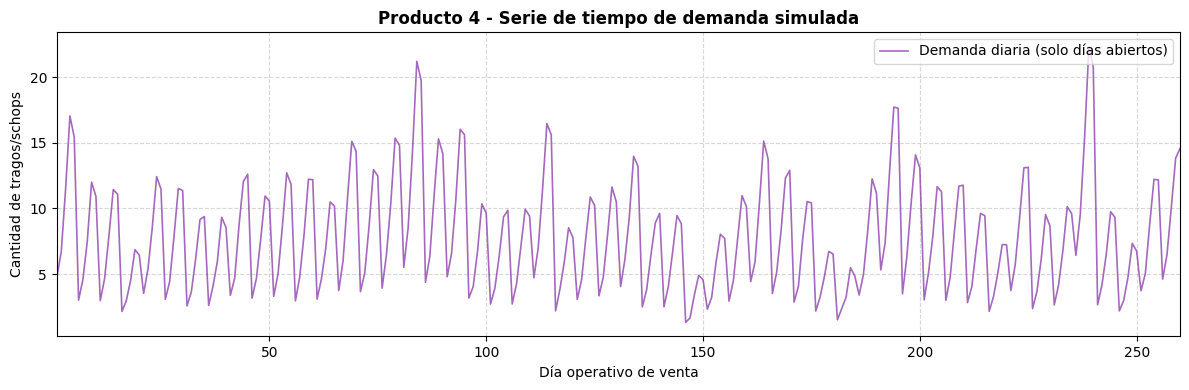

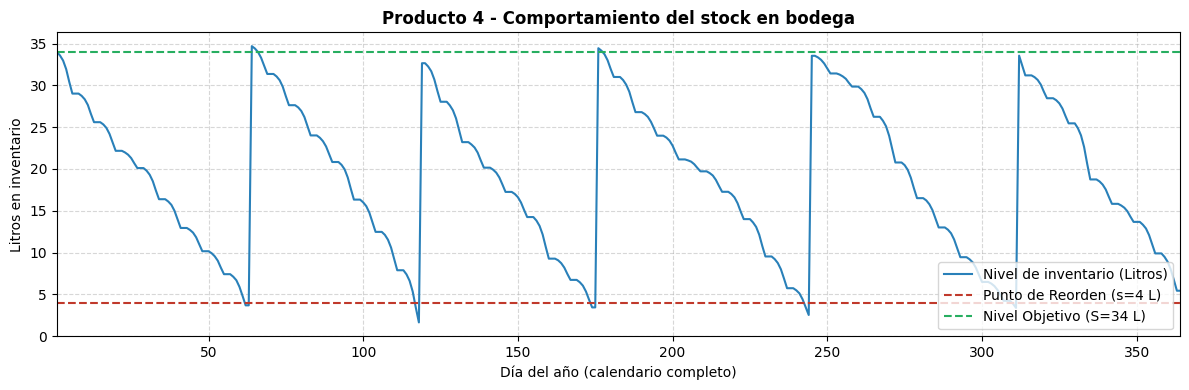

--------------------------------------------------------------------------------


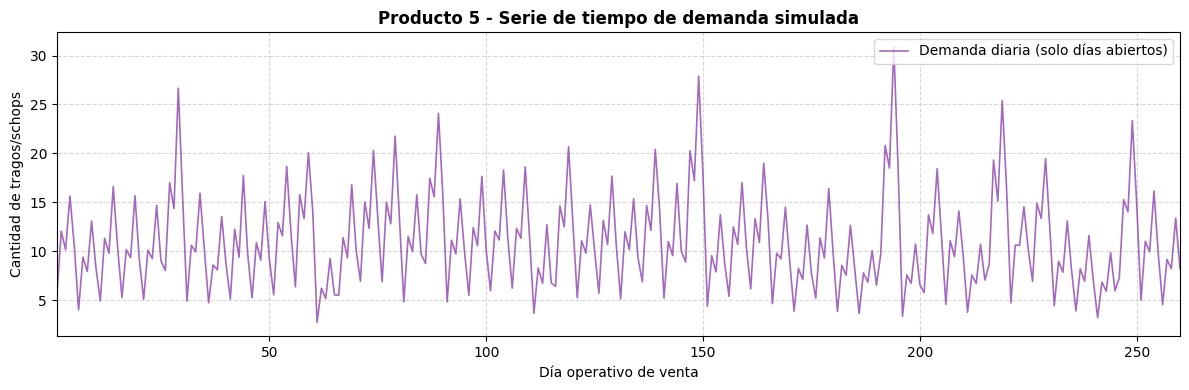

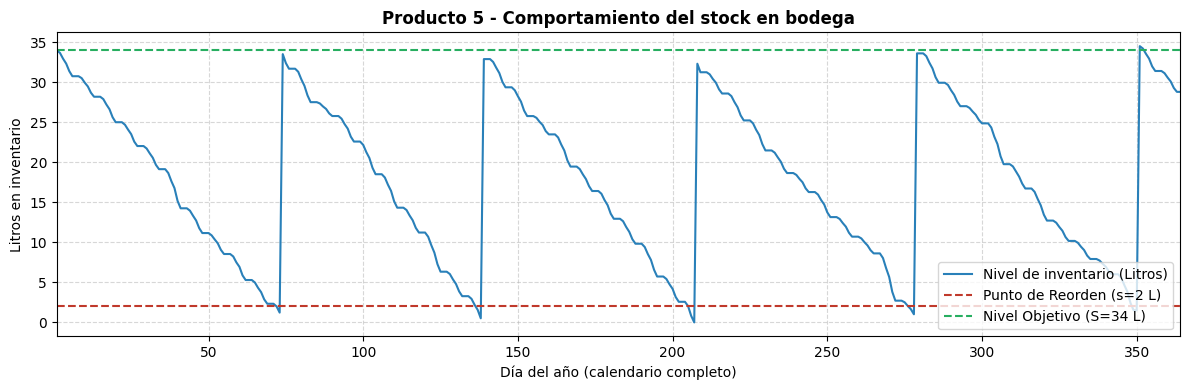

--------------------------------------------------------------------------------


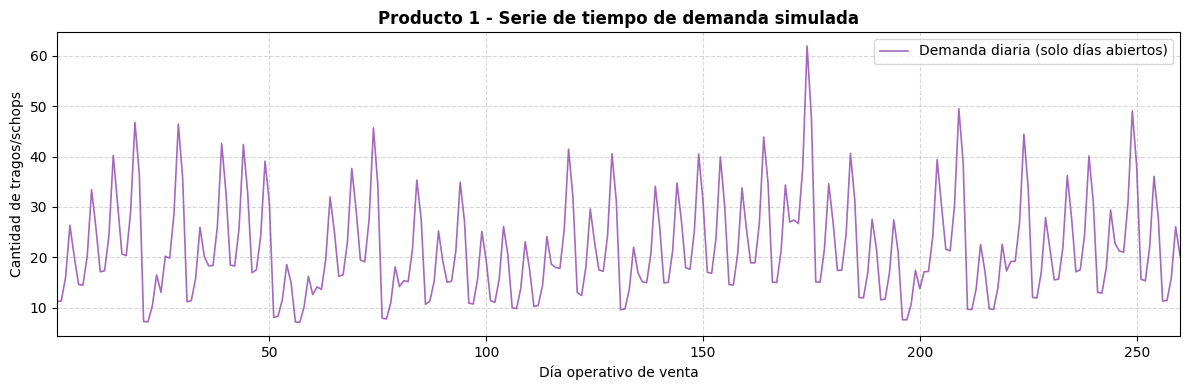

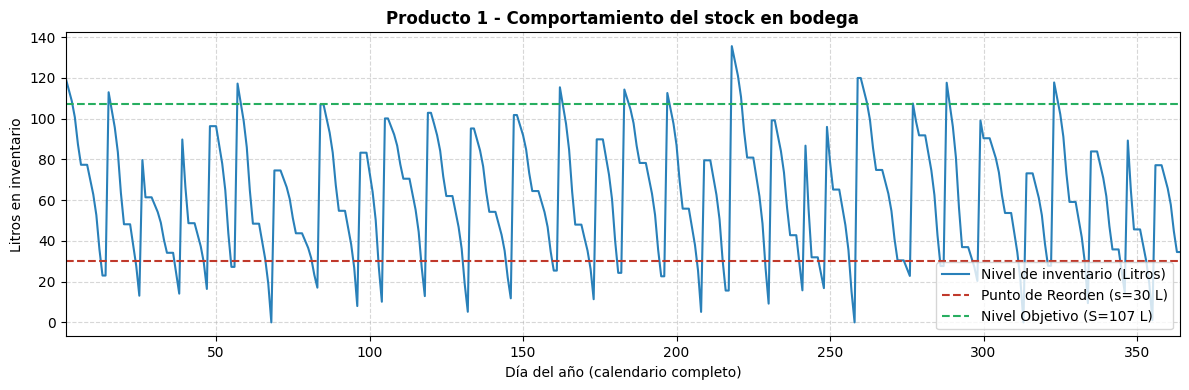

--------------------------------------------------------------------------------


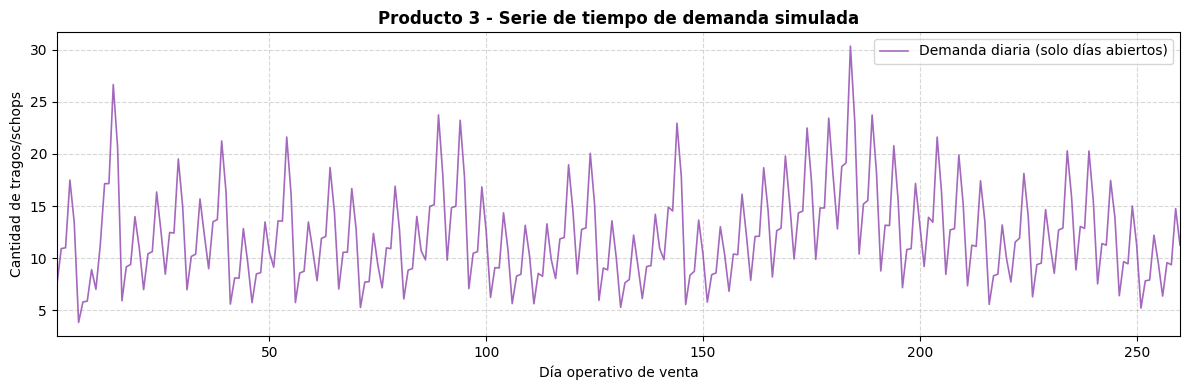

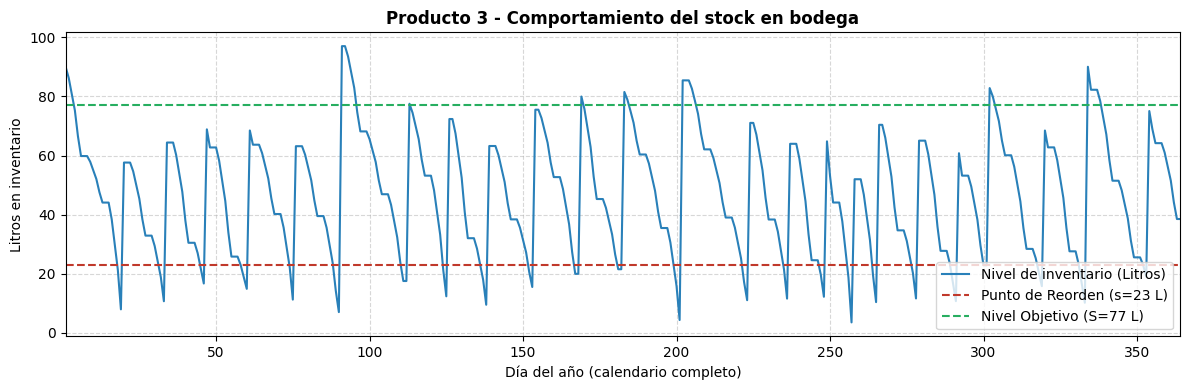

--------------------------------------------------------------------------------


In [6]:
# ==============================================================================
# GRÁFICOS (DEMANDA EN TRAGOS vs INVENTARIO EN LITROS)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*80)
print("GENERACIÓN DE GRÁFICOS: DEMANDA (TRAGOS/SCHOPS) E INVENTARIO (LITROS)")
print("="*80)

# 1. Diccionario de nombres oficiales para la tesis (Sin paréntesis)
nombres_tesis = {
    1: "Producto 2", # Mojito
    2: "Producto 4", # Pink Flower
    3: "Producto 5", # Mistral
    4: "Producto 1", # Heineken
    5: "Producto 3"  # Austral Calafate
}

# 2. Factor de conversión: Litros por cada vaso/schop
litros_por_trago = {
    1: 0.09,  # P1 Interno: Mojito (90 cc)
    2: 0.09,  # P2 Interno: Pink Flower (90 cc)
    3: 0.06,  # P3 Interno: Mistral (60 cc)
    4: 0.50,  # P4 Interno: Heineken (500 cc)
    5: 0.50   # P5 Interno: Austral (500 cc)
}

if df_diario is not None and not df_diario.empty:
    for p_id in range(1, 6): # Recorrer los 5 productos (según el ID de Python)

        # Filtrar datos de la primera réplica para el producto actual
        df_prod = df_diario[df_diario['producto'] == p_id].sort_values('día')

        nombre_grafico = nombres_tesis[p_id]
        factor_trago = litros_por_trago[p_id]

        # ---------------------------------------------------------
        # PREPARACIÓN DE DATOS: GRÁFICO 1 (DEMANDA EN TRAGOS - Solo días abiertos)
        # ---------------------------------------------------------
        # Filtramos excluyendo Lunes y Domingos
        df_demanda_abierta = df_prod[~df_prod['nombre_dia'].isin(['Lunes', 'Domingo'])]

        # Creamos un eje X secuencial para evitar espacios en blanco
        dias_operativos = np.arange(1, len(df_demanda_abierta) + 1)

        # CONVERSIÓN: De litros a cantidad de tragos/schops
        ventas_simuladas_tragos = df_demanda_abierta['demanda_unidades'] / factor_trago

        # ---------------------------------------------------------
        # PREPARACIÓN DE DATOS: GRÁFICO 2 (INVENTARIO EN LITROS - Todos los días)
        # ---------------------------------------------------------
        dias_totales = df_prod['día']
        inventario = df_prod['inv_final_unidades']

        # ---------------------------------------------------------
        # GRÁFICO 1: VENTAS SIMULADAS (En tragos/schops)
        # ---------------------------------------------------------
        plt.figure(figsize=(12, 4))
        plt.plot(dias_operativos, ventas_simuladas_tragos, color='#8E44AD', alpha=0.8, linewidth=1.2, label='Demanda diaria (solo días abiertos)')

        plt.title(f"{nombre_grafico} - Serie de tiempo de demanda simulada", fontsize=12, fontweight='bold')
        plt.ylabel("Cantidad de tragos/schops", fontsize=10) # Etiqueta actualizada
        plt.xlabel("Día operativo de venta", fontsize=10)

        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xlim(dias_operativos.min(), dias_operativos.max())

        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------------
        # GRÁFICO 2: EVOLUCIÓN DEL INVENTARIO (En Litros)
        # ---------------------------------------------------------
        plt.figure(figsize=(12, 4))
        plt.plot(dias_totales, inventario, color='#2980B9', linewidth=1.5, label='Nivel de inventario (Litros)')

        # Dibujar las líneas de la política s y S
        s_val = s_opt[p_id-1]
        S_val = S_opt[p_id-1]
        plt.axhline(y=s_val, color='#C0392B', linestyle='--', linewidth=1.5, label=f'Punto de Reorden (s={s_val} L)')
        plt.axhline(y=S_val, color='#27AE60', linestyle='--', linewidth=1.5, label=f'Nivel Objetivo (S={S_val} L)')

        plt.title(f"{nombre_grafico} - Comportamiento del stock en bodega", fontsize=12, fontweight='bold')
        plt.ylabel("Litros en inventario", fontsize=10)
        plt.xlabel("Día del año (calendario completo)", fontsize=10)

        plt.legend(loc='lower right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xlim(dias_totales.min(), dias_totales.max())

        plt.tight_layout()
        plt.show()

        print("-" * 80)

else:
    print("Error: No hay datos en 'df_diario'. Asegúrate de correr la simulación con return_full_dfs=True")

In [7]:
# ==============================================================================
# VERIFICACIÓN OPERATIVA: DEMANDA POR DÍA DE LA SEMANA (DÍAS DE CIERRE)
# ==============================================================================
import pandas as pd

print("\n" + "="*60)
print("COMPROBACIÓN DE DÍAS DE CIERRE (DEMANDA CERO)")
print("="*60)

if df_diario is not None and not df_diario.empty:
    # Definimos el orden lógico de los días para que la tabla se lea bien
    orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

    # Tomamos el Producto 1 (Heineken) como demostración. La regla aplica a todos.
    df_prueba = df_diario[df_diario['producto'] == 1]

    # Agrupamos por el nombre del día
    resumen_dias = df_prueba.groupby('nombre_dia')['demanda_unidades'].agg(
        Días_Simulados='count',
        Venta_Total_Litros='sum',
        Promedio_Diario='mean'
    ).reindex(orden_dias)

    print("Producto: Heineken (Ejemplo de validación)")
    print(resumen_dias.to_string())
    print("-" * 60)

    # Verificación automática
    ventas_lunes = resumen_dias.loc['Lunes', 'Venta_Total_Litros']
    ventas_domingo = resumen_dias.loc['Domingo', 'Venta_Total_Litros']

    if ventas_lunes == 0 and ventas_domingo == 0:
        print("✅ VALIDACIÓN EXITOSA: El simulador respeta estrictamente los días de cierre.")
        print("   (La demanda en Lunes y Domingo es exactamente 0.0 litros).")
    else:
        print("❌ ALERTA: Hay ventas registradas en días que deberían estar cerrados.")
else:
    print("Error: No hay datos en df_diario.")


COMPROBACIÓN DE DÍAS DE CIERRE (DEMANDA CERO)
Producto: Heineken (Ejemplo de validación)
            Días_Simulados  Venta_Total_Litros  Promedio_Diario
nombre_dia                                                     
Lunes                   52               0.000         0.000000
Martes                  52              31.038         0.596885
Miércoles               52              43.194         0.830654
Jueves                  52              61.402         1.180808
Viernes                 52              97.829         1.881327
Sábado                  52              85.797         1.649942
Domingo                 52               0.000         0.000000
------------------------------------------------------------
✅ VALIDACIÓN EXITOSA: El simulador respeta estrictamente los días de cierre.
   (La demanda en Lunes y Domingo es exactamente 0.0 litros).


In [11]:
# ==============================================================================
# MÉTRICAS DE LA DEMANDA SIMULADA
# ==============================================================================

print("\n" + "="*60)
print("MÉTRICAS GLOBALES DE DEMANDA (200 RÉPLICAS)")
print("="*60)

rng_base = np.random.default_rng(RANDOM_SEED)
P = len(DEMAND_CONFIG)
total_days = HORIZON_WEEKS * 7

demanda_global = np.zeros((P, MC_REPL_FINAL * total_days))

for r in range(MC_REPL_FINAL):
    rng = np.random.default_rng(rng_base.integers(1_000_000_000))
    weekly_demands = [sample_weekly_demand(DEMAND_CONFIG[i], HORIZON_WEEKS, rng) for i in range(P)]
    
    for i in range(P):
        idx_inicio = r * total_days
        for w in range(HORIZON_WEEKS):
            alloc = allocate_weekly_to_days(float(weekly_demands[i][w]), rng, DAILY_WEIGHTS_MATRIX[i])
            demanda_global[i, idx_inicio + w*7 : idx_inicio + (w+1)*7] = alloc

nombres_productos_codigo = {
    0: "Mojito (Ron)", 
    1: "Pink Flower (Gin)", 
    2: "Mistral", 
    3: "Heineken", 
    4: "Austral Calafate"
}

for i in range(P):
    vector_demanda = demanda_global[i, :]
    
    media = np.mean(vector_demanda)
    varianza = np.var(vector_demanda, ddof=1)
    desv_std = np.std(vector_demanda, ddof=1)
    cv = desv_std / media if media != 0 else 0
    
    print(f"Índice Código {i} -> {nombres_productos_codigo[i]}")
    print(f"  -> Media Diaria Esperada : {media:.4f} litros")
    print(f"  -> Varianza Global       : {varianza:.4f}")
    print(f"  -> Desviación Estándar   : {desv_std:.4f} litros")
    print(f"  -> Coef. de Variación    : {cv:.4f}")
    print("-" * 60)


MÉTRICAS GLOBALES DE DEMANDA (200 RÉPLICAS)
Índice Código 0 -> Mojito (Ron)
  -> Media Diaria Esperada : 0.9279 litros
  -> Varianza Global       : 0.6075
  -> Desviación Estándar   : 0.7794 litros
  -> Coef. de Variación    : 0.8400
------------------------------------------------------------
Índice Código 1 -> Pink Flower (Gin)
  -> Media Diaria Esperada : 0.5179 litros
  -> Varianza Global       : 0.2146
  -> Desviación Estándar   : 0.4633 litros
  -> Coef. de Variación    : 0.8945
------------------------------------------------------------
Índice Código 2 -> Mistral
  -> Media Diaria Esperada : 0.4373 litros
  -> Varianza Global       : 0.1299
  -> Desviación Estándar   : 0.3604 litros
  -> Coef. de Variación    : 0.8240
------------------------------------------------------------
Índice Código 3 -> Heineken
  -> Media Diaria Esperada : 7.2941 litros
  -> Varianza Global       : 35.0630
  -> Desviación Estándar   : 5.9214 litros
  -> Coef. de Variación    : 0.8118
---------------